# Validate fire products against ground-truth references

This notebook is the **accuracy** companion to `run_fire_comparison.ipynb`. That
notebook asks *"do the products agree with each other?"* (no truth). This one asks
*"is a product **right**?"* — it scores each remotely-sensed product against
independent reference fire perimeters (NIFC large fires, TNC preserve burns,
NCWRC prescribed fires) curated with Margaret's help.

**What the metrics mean (read this first):**
- **recall = 1 − omission** is the headline number: of a known fire's footprint,
  the fraction the product detected. Clean, because a fire definitely occurred
  inside the perimeter.
- **precision** is reported only *per event, inside a buffered window*, and is
  **conditional**: the references are not a complete census (a product burn
  outside them may be a real small fire, not a false alarm), and a perimeter is
  an *outer boundary* that includes unburned islands (it overestimates truth).
- Scoring is **time-matched, per event** — each incident vs the product layer for
  its own year. Active fire (VIIRS) is judged at the event level (`detected`),
  and is 2012+ so it is simply absent for the older fires.

See `decisions.md` → *Ground-truth validation toolkit* for the full rationale.

## 0. Setup & AOI

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from peatfire import data_path
from peatfire.fire_products_comparison import (
    list_references, get_reference, load_reference, reference_event_table,
    validate_event, validate_products, summarize_validation, recall_matrix,
    confusion_scores, rasterize_polygons_to_grid, build_common_grid,
    stack_on_common_grid, list_products,
    set_fire_style, plot_validation_heatmap,
    plot_reference_vs_product_for_one_event, plot_event_perimeter,
    overlay_aoi_boundaries,
)

set_fire_style()

# Same AOI swap-in as the comparison notebook: NC / peatlands / coastal plain all work.
aoi = gpd.read_file(data_path("processed", "boundaries", "nc_boundary.gpkg"))

## 1. What references are registered, and what's on disk?

Each reference is a vector source of fire perimeters. A source whose folder is
missing skips with a warning (like the products), so this runs on whatever you've
downloaded. Expected processed layout (clip the raw NIFC gpkgs in
`download_and_clip_data.ipynb` first):

```
data/processed/fire/reference/nifc_ifph/nifc_ifph_*.gpkg   # default NIFC source
data/processed/fire/reference/geomac/geomac_*.gpkg         # 2000-2018 cross-check
data/processed/fire/reference/tnc_burns/tnc_burns_*.shp
```

In [2]:
rows = []
for name in list_references():
    s = get_reference(name)
    n = len(sorted(s.directory.glob(s.glob))) if s.directory.exists() else 0
    rows.append({"reference": name, "kind": s.kind, "dir_exists": s.directory.exists(),
                 "n_files": n, "directory": str(s.directory)})
pd.DataFrame(rows).set_index("reference")

,kind,dir_exists,n_files,directory
reference,,,,
NIFC_IFPH,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
GEOMAC,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
TNC_SANDHILLS,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
TNC_COASTAL_PLAIN,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
NCWRC_RX,perimeter,False,0,/Users/jinjiang-macair/Library/CloudStorage/On...


## 2. The event menu

`reference_event_table` lists every incident in the source within the AOI — your
menu of fires to validate against, and where to find Margaret's named events
(Evans Road 2008, Pains Bay 2011, Juniper Road 2011, Whipping Creek 2016,
Great Lakes 2023, ...).

## 3. Validate one event in detail

`validate_event` takes one perimeter row, builds a buffered analysis-window grid
around it, rasterises the perimeter to the "reference burned" mask, loads every
product on that same grid for the event's year, and returns per-product
recall / precision / detected. Pick a Margaret fire by name.

In [3]:
products = list_products("burned_area")
products

['MCD64A1', 'GABAM', 'FireCCI51', 'FireCCIS311']

In [19]:
ref = load_reference("TNC_COASTAL_PLAIN", aoi)
ref.sort_values(by='ACREAGE', ascending=False)

,START_DATE,PRESERVE,BURN_UNIT,ACREAGE,BURN_BOSS,TYPE_OF_BU,Drone,COUNTY,FIRE_TREAT,Year,COMMENTS,END_DATE,RESTORATIO,Shape__Len,Shape__Are,geometry,_year,_month,_event,_area
580,2023-06-15,Green Swamp,NaN,15106.865178,NaN,NaN,NaN,BRUNSWICK,WILDFIRE,2023.0,Pulp Road Fire; Shane Hardee IC,2023-06-21,0.0,47877.444806,8.938186e+07,"POLYGON ((-8705509.73 4047117.451, -8705509.68...",2023.0,6.0,<NA>,15106.865178
582,NaT,Green Swamp,NaN,9778.404357,NaN,BROADCAST,NaN,BRUNSWICK,WILDFIRE,1969.0,NaN,NaT,0.0,41418.816317,5.786946e+07,"MULTIPOLYGON (((-8705622.201 4046633.168, -870...",1969.0,NaN,<NA>,9778.404357
584,NaT,Green Swamp,NaN,3577.135438,NaN,BROADCAST,NaN,BRUNSWICK,WILDFIRE,1982.0,NaN,NaT,0.0,20234.154767,2.116276e+07,"POLYGON ((-8715871.187 4042556.986, -8714636.2...",1982.0,NaN,<NA>,3577.135438
253,2010-01-05,Shaken Creek,SC Shaken Creek 1,1424.634929,ALLEN OLMSTEAD,BROADCAST,NaN,PENDER,PRESCRIBED FIRE,2010.0,NaN,2010-03-08,0.0,22511.432902,8.529233e+06,"POLYGON ((-8649769.309 4110437.821, -8649537.0...",2010.0,1.0,SC Shaken Creek 1,1424.634929
583,NaT,Green Swamp,NaN,913.915288,NaN,BROADCAST,NaN,BRUNSWICK,WILDFIRE,1980.0,NaN,NaT,0.0,11604.060275,5.410168e+06,"POLYGON ((-8707025.044 4047099.624, -8707057.5...",1980.0,NaN,<NA>,913.915288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,2022-03-28,Angola Creek,Private Lands,1.695021,BOB BALE,NaN,NaN,ONSLOW,WILDFIRE,2022.0,Escape. N. Burmester RxB2(t),2022-03-28,0.0,554.782430,1.017457e+04,"POLYGON ((-8650437.816 4124331.042, -8650464.3...",2022.0,3.0,Private Lands,1.695021
212,2007-02-11,Shaken Creek,SC 3a,1.591660,ALLEN OLMSTEAD,BROADCAST,NaN,PENDER,PRESCRIBED FIRE,2007.0,outside of units,2007-02-26,0.0,401.867122,9.528697e+03,"POLYGON ((-8646126.866 4109264.978, -8646078.6...",2007.0,2.0,SC 3a,1.591660
219,2007-02-11,Shaken Creek,SC Shelter Swamp,1.309070,ALLEN OLMSTEAD,BROADCAST,NaN,PENDER,PRESCRIBED FIRE,2007.0,NaN,2007-02-26,0.0,481.293515,7.837918e+03,"POLYGON ((-8643852.863 4109866.051, -8643847.2...",2007.0,2.0,SC Shelter Swamp,1.309070
232,2007-02-11,Shaken Creek,SC Unit 3,1.274803,ALLEN OLMSTEAD,BROADCAST,NaN,PENDER,PRESCRIBED FIRE,2007.0,NaN,2007-02-26,0.0,449.266534,7.627747e+03,"POLYGON ((-8647165.556 4106266.467, -8647127.9...",2007.0,2.0,SC Unit 3,1.274803


In [4]:
ref = load_reference("NIFC_IFPH", aoi)
if ref is not None:
    # pick one event by name substring (case-insensitive); fall back to the first row
    hit = ref[ref["_event"].str.contains("Evans Road", case=False, na=False)]
    event_gdf = hit if len(hit) else ref.iloc[[0]]
    year = int(event_gdf["_year"].iloc[0])
    print("event:", event_gdf["_event"].iloc[0], "| year:", year)
    detail_one = validate_event(
        event_gdf,
        products=list_products("burned_area") + list_products("occurrence"),
        year=year, buffer_km=5.0,
    )
    display(detail_one[["event", "year", "product", "family",
                        "recall", "precision", "detected", "n_ref", "n_prod"]])
else:
    print("NIFC_IFPH not downloaded yet — skipping.")

event: JOE BROWN | year: 2023


,event,year,product,family,recall,precision,detected,n_ref,n_prod
0,JOE BROWN,2023,MCD64A1,burned_area,0.0,NaN,False,3,0
1,JOE BROWN,2023,FireCCIS311,burned_area,0.0,NaN,False,3,0


## 3b. *See* one event vs a product on a map

The table above gives the numbers; this puts them on a map. For a chosen
reference event, `plot_reference_vs_product_for_one_event` time-matches the
product, rasterises the perimeter onto the **same common grid**, and draws the
reference-vs-product **confusion overlay** (the categorical encoding reused from
`plot_overlay_map`): blue = reference only (**omission** — the product missed
it), red = product only (commission), purple = **both** (hit). The actual event
perimeter is outlined on top, and `aoi_context` (e.g. the NC outline) is drawn
for geographic reference — generalising the manual "overlay `aoi_nc`, then
restore the view" step into `overlay_aoi_boundaries`.

`extent="event"` (default) zooms to a `buffer_km` window so a single incident is
legible; `extent="aoi"` maps the whole AOI as the backdrop instead. The figure is
saved with the event name in the filename when `out_dir` is given.

In [20]:
events = ['Carvers Creek', 'Green Swamp']
products = list_products("burned_area") + list_products("occurrence")
ba = set(list_products("burned_area"))          # compute once, not per product

for event in events:
    for ref in list_references():
        try:
            # "Where is this fire?" -- perimeter only, no product/grid
            fig = plot_event_perimeter(
                reference=ref, aoi=aoi, event=event,
                fill=True, aoi_context=aoi,
                out_dir="../outputs/figures/fire",
            )
            plt.close(fig)
        except ValueError:
            # this reference doesn't contain this event (or it's outside the AOI)
            continue                            # -> skip the products too: same miss

        for product in products:
            try:
                fig = plot_reference_vs_product_for_one_event(
                    reference=ref, product=product, aoi=aoi, event=event,
                    binary=product in ba,        # BA -> confusion overlay; else raster
                    extent="event", buffer_km=10.0,
                    aoi_context=aoi,
                    out_dir="../outputs/figures/fire",
                )
                plt.close(fig)
            except ValueError:
                continue

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/fire_products_comparison/reference_sources.py:300: UserWarning: NCWRC_RX: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/fire/reference/ncwrc_rx does not exist -- skipping.
  gdf = _read_all(spec)
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/fire_products_comparison/reference_sources.py:300: UserWarning: NCWRC_RX: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/fire/reference/ncwrc_rx does not exist -- skipping.
  gdf = _read_all(spec)


## 4. Validate across all events of a source

`validate_products` runs every event of a reference, time-matched, and returns one
tidy row per (event, product). `min_acres` focuses on mappable incidents;
`match="month"` tightens timing when the source carries dates.

In [ ]:
detail = validate_products(
    "NIFC_IFPH", aoi,
    products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"],
    buffer_km=5.0, min_acres=100.0, match="year",
)
detail.head(20) if not detail.empty else "no events scored (source not downloaded?)"

,source,event,year,month,product,family,tp,fn,fp,n_ref,n_prod,recall,precision,detected
0,NIFC_IFPH,SADDLE MT.,1985,None,GABAM,burned_area,0,7,0,7,0,0.000000,NaN,False
1,NIFC_IFPH,FORNEY CR,1998,None,GABAM,burned_area,0,18,0,18,0,0.000000,NaN,False
2,NIFC_IFPH,MERRITT CK,2000,None,MCD64A1,burned_area,0,16,0,16,0,0.000000,NaN,False
3,NIFC_IFPH,MERRITT CK,2000,None,GABAM,burned_area,0,16,0,16,0,0.000000,NaN,False
4,NIFC_IFPH,CEDAR RIDG,2000,None,MCD64A1,burned_area,0,13,0,13,0,0.000000,NaN,False
5,NIFC_IFPH,CEDAR RIDG,2000,None,GABAM,burned_area,0,13,2,13,2,0.000000,0.000000,False
6,NIFC_IFPH,TUNNEL,2001,None,MCD64A1,burned_area,0,27,0,27,0,0.000000,NaN,False
7,NIFC_IFPH,TUNNEL,2001,None,GABAM,burned_area,0,27,30,27,30,0.000000,0.000000,False
8,NIFC_IFPH,TUNNEL,2001,None,FireCCI51,burned_area,0,27,44,27,44,0.000000,0.000000,False
9,NIFC_IFPH,SHARP,2001,None,MCD64A1,burned_area,0,146,0,146,0,0.000000,NaN,False


## 5. Per-product roll-up

`recall_pooled` is cell-weighted (dominated by the big fires — "what fraction of
burned *area* was caught?"). `recall_mean_event` weights each fire equally
(surfaces small-fire omission). `detection_rate` = fraction of fires the product
saw at all. The precision column is the conditional within-window number.

In [9]:
if not detail.empty:
    display(summarize_validation(detail).round(3))

,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCI51,36,0.528,0.120,0.167,0.410
MCD64A1,59,0.513,0.132,0.203,0.363
FireCCIS311,31,0.497,0.193,0.387,0.418
GABAM,45,0.339,0.097,0.267,0.381
VIIRS,45,0.258,0.169,0.689,0.532


## 6. Events × products recall heatmap

Each row is one reference fire, each column a product — so per-incident strengths
and weaknesses read straight off. (e.g. does any product miss the escaped-Rx Dad
Fire, which only shows a remote signal for ~a year?)

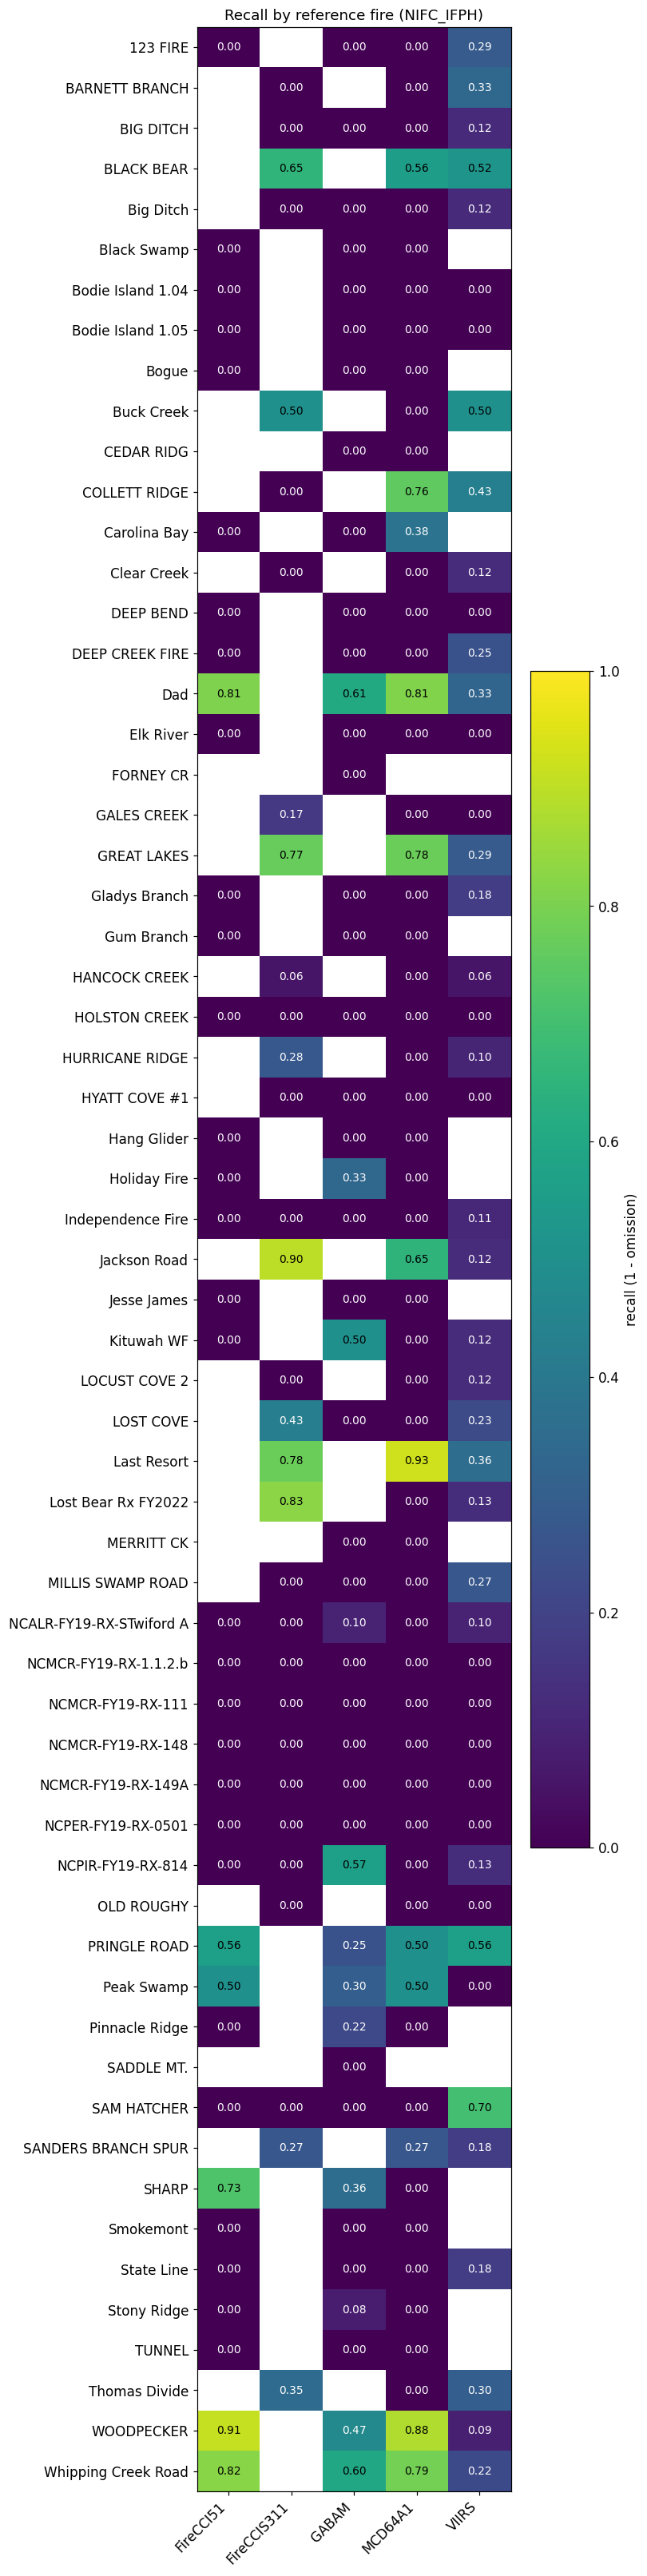

In [10]:
if not detail.empty:
    m = recall_matrix(detail, value="recall")
    plot_validation_heatmap(m, title="Recall by reference fire (NIFC_IFPH)")
    plt.savefig("../outputs/figures/fire/validation_recall_nifc_ifph.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 7. Small-fire references (TNC / NCWRC)

TNC preserve burns and NCWRC prescribed fires are *small* — a stress test of the
small-fire omission that coarse products (MCD64A1 500 m) are expected to fail.
Compare `recall_mean_event` here against the big-fire NIFC table above.

In [13]:
for src in ["NIFC_IFPH", "GEOMAC", "TNC_SANDHILLS", "TNC_COASTAL_PLAIN", "NCWRC_RX"]:
    d = validate_products(src, aoi, products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"])
    if d.empty:
        print(f"{src}: not downloaded — skipping"); continue
    print(f"=== {src} ===")
    display(summarize_validation(d).round(3))

=== NIFC_IFPH ===


,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCIS311,93,0.433,0.083,0.172,0.248
MCD64A1,204,0.432,0.043,0.064,0.198
FireCCI51,132,0.425,0.037,0.053,0.158
GABAM,185,0.266,0.040,0.103,0.217
VIIRS,134,0.234,0.094,0.343,0.282


=== GEOMAC ===


,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCI51,85,0.683,0.302,0.388,0.434
MCD64A1,85,0.632,0.243,0.400,0.418
VIIRS,66,0.500,0.294,0.682,0.525
GABAM,85,0.489,0.188,0.412,0.569


=== TNC_SANDHILLS ===


,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCIS311,124,0.290,0.280,0.484,0.047
VIIRS,303,0.229,0.230,0.634,0.049
GABAM,348,0.118,0.113,0.259,0.097
FireCCI51,329,0.051,0.045,0.070,0.029
MCD64A1,441,0.026,0.025,0.075,0.049


=== TNC_COASTAL_PLAIN ===


,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCIS311,227,0.312,0.154,0.286,0.098
VIIRS,457,0.142,0.126,0.473,0.133
GABAM,467,0.119,0.089,0.208,0.117
MCD64A1,626,0.090,0.028,0.056,0.053
FireCCI51,410,0.042,0.026,0.054,0.063


NCWRC_RX: not downloaded — skipping


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/fire_products_comparison/reference_sources.py:300: UserWarning: NCWRC_RX: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/fire/reference/ncwrc_rx does not exist -- skipping.
  gdf = _read_all(spec)


## 8. GeoMAC cross-check (do NOT pool with NIFC_IFPH)

GeoMAC (2000-2018) overlaps NIFC_IFPH, so the *same* fire is in both — pooling
double-counts. Run it separately as an independent cross-check on those years.

In [12]:
d_geomac = validate_products("GEOMAC", aoi,
                             products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"],
                             years=range(2000, 2019), min_acres=100.0)
if not d_geomac.empty:
    display(summarize_validation(d_geomac).round(3))

,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCI51,60,0.693,0.392,0.500,0.547
MCD64A1,60,0.641,0.329,0.533,0.508
VIIRS,43,0.512,0.415,0.907,0.697
GABAM,60,0.496,0.266,0.583,0.666


## 9. Note on severity

Perimeters carry **no severity** and we have no field CBI, so severity products
(SE FireMap, MOSEV, MTBS) are *not* scored here. Their proper validation use is to
**restrict the severity cross-comparison to reference cells** — i.e. compare them
only where a fire is known to have burned. Do that in `run_fire_comparison.ipynb`
by intersecting the severity stack with a rasterised reference mask
(`rasterize_polygons_to_grid`).

In [14]:
import geopandas as gpd
from peatfire import data_path

for f in [data_path('raw', 'fire', 'reference', 'TNC_NC_Sandhills_Fire_History_2025', 'TNC_NC_Sandhills_Fire_History_2025.shp'),
          data_path('raw', 'fire', 'reference', 'TNC_NC_Coastal_Plain_Fire_History_2025', 'TNC_NC_Coastal_Plain_Fire_History_2025.shp')]:
    
    g = gpd.read_file(f, rows=1)
    print(g.crs, list(g.columns))

EPSG:3857 ['START_DATE', 'PRESERVE', 'BURN_UNIT', 'ACREAGE', 'BURN_BOSS', 'TYPE_OF_BU', 'Drone', 'FIRE_TREAT', 'END_DATE', 'COMMENTS', 'YEAR', 'COUNTY', 'RESTORATIO', 'MONTH', 'Shape__Len', 'Shape__Are', 'geometry']
EPSG:3857 ['START_DATE', 'PRESERVE', 'BURN_UNIT', 'ACREAGE', 'BURN_BOSS', 'TYPE_OF_BU', 'Drone', 'COUNTY', 'FIRE_TREAT', 'Year', 'COMMENTS', 'END_DATE', 'RESTORATIO', 'Shape__Len', 'Shape__Are', 'geometry']
